In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
import seaborn as sns

In [2]:
counts_log = pd.read_csv("../data/processed/log2_counts.csv", index_col=0)
metadata = pd.read_csv("../data/processed/metadata.csv")

counts_log.shape, metadata.shape

((144, 39376), (162, 4))

In [3]:
metadata = metadata.set_index("sample_id")
metadata = metadata.loc[counts_log.index]

metadata.head()

,sample_title,group,binary_class
GSM8084969,TSC_1,TSC,Epilepsy
GSM8084970,TSC_2,TSC,Epilepsy
GSM8084971,FCD2a_1,FCD2a,Epilepsy
GSM8084972,FCD2a_2,FCD2a,Epilepsy
GSM8084973,ControlCortex_1,ControlCortex,Control


In [5]:
gene_variance = counts_log.var(axis=0)

top_genes = gene_variance.sort_values(ascending=False).head(5000).index

X = counts_log[top_genes]

X.shape

(144, 5000)

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
pca = PCA(n_components=2)

pca_df = pd.DataFrame(
    pca.fit_transform(X_scaled),
    columns=["PC1", "PC2"],
    index=counts_log.index
)

pca_df["group"] = metadata["group"]
pca_df["binary_class"] = metadata["binary_class"]

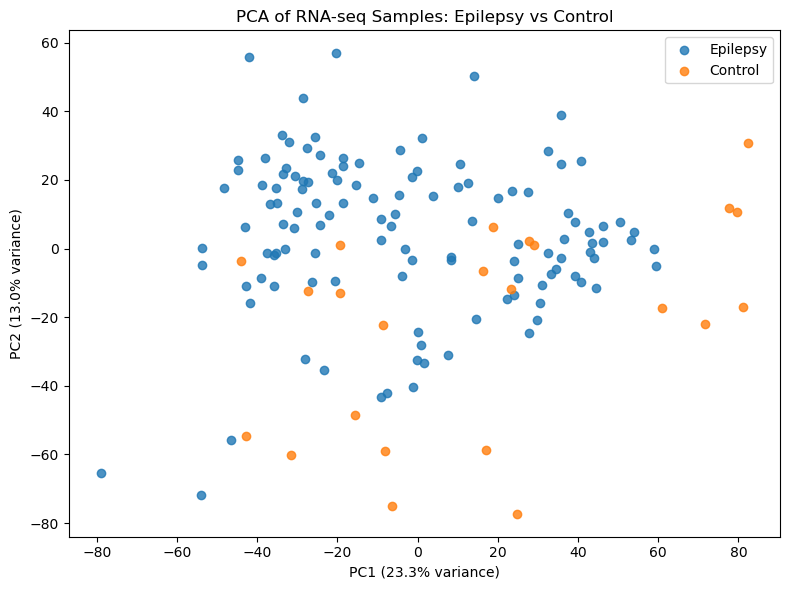

In [14]:
plt.figure(figsize=(8, 6))

for label in pca_df["binary_class"].unique():
    subset = pca_df[pca_df["binary_class"] == label]
    plt.scatter(subset["PC1"], subset["PC2"], label=label, alpha=0.8)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of RNA-seq Samples: Epilepsy vs Control")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/pca_binary_class.png", dpi=300)
plt.show()

No obvious clear seperation of gene expression. Not strongly separating disease from control.

In [16]:
print(
    pca.explained_variance_ratio_,
    pca.explained_variance_ratio_.sum()
)

[0.23294402 0.13047869] 0.3634227039064576


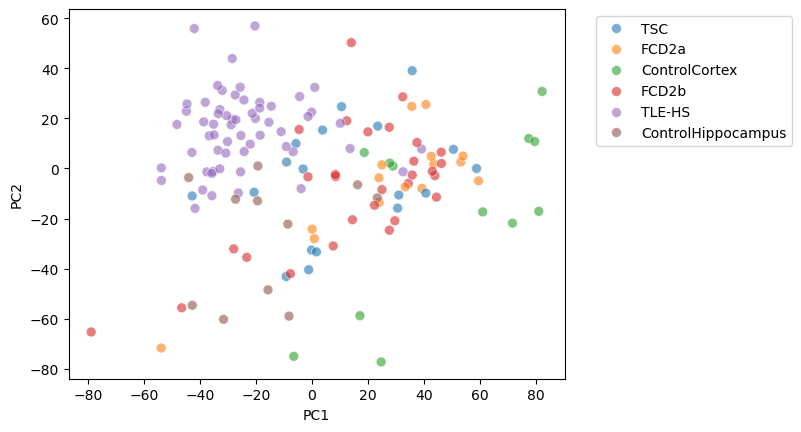

In [36]:
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="group",
    alpha=0.6,
    s=50
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

TLE-HS has obvious clustering.

Control cortex tends to shift to the right - perhaps a source contributing to to variation.

FCD2a and FCD2b have overlap.

TSC appears scattered across the center, no clustering.

Control samples were distributed separately along PC1, suggesting tissue-specific expression patterns may contribute substantially to overall variance.

In [37]:
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

X_umap.shape

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(144, 2)

In [32]:
umap_df = pd.DataFrame(
    X_umap,
    columns=["UMAP1", "UMAP2"],
    index=counts_log.index
)

umap_df["group"] = metadata["group"]
umap_df["binary_class"] = metadata["binary_class"]

umap_df.head()

,UMAP1,UMAP2,group,binary_class
GSM8084969,6.139543,4.821074,TSC,Epilepsy
GSM8084970,6.049608,4.870816,TSC,Epilepsy
GSM8084971,7.759927,4.404554,FCD2a,Epilepsy
GSM8084972,8.737273,4.317820,FCD2a,Epilepsy
GSM8084973,6.291804,2.016687,ControlCortex,Control


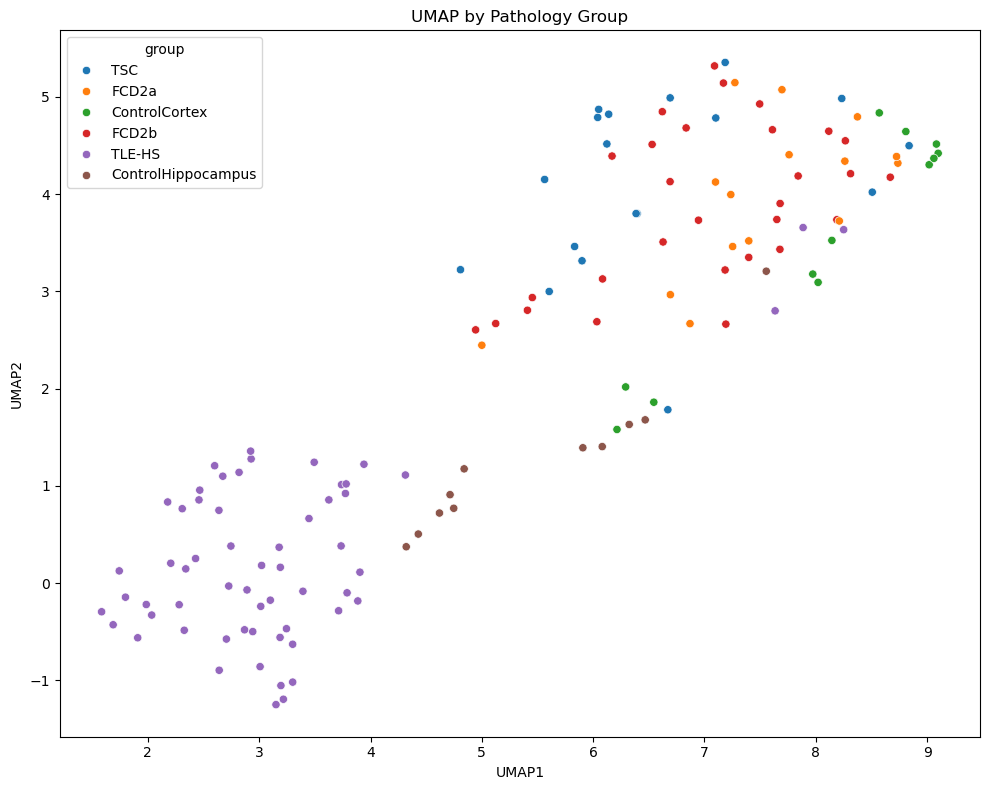

In [38]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="group"
)

plt.title("UMAP by Pathology Group")
plt.tight_layout()
plt.show()

UMAP revealed a distinct cluster of TLE-HS samples. This implies a transcriptional profile that differs substantially from the other epilepsy pathologies.

FCD2a, FCD2b and TSC overlap without clear seperation.

ControlCortex leans towards the right side of the graph

